In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

sns.set_theme(style='darkgrid')

In [ ]:
df = pd.read_csv('datasets/titanic.csv')
# Check the features with missing values
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [3]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
target = ['Survived']
X = df[features].copy()
y = df[target]

X['Sex'] = X['Sex'].map({'male': 1, 'female': 0})
X['Age'] = X['Age'].fillna(X['Age'].median())


In [4]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=123)

In [5]:
model = XGBClassifier()
model.fit(x_train, y_train)

y_train_pred = model.predict(x_train)
print("::::::::::::::::::::::::: Training Metrics ::::::::::::::::::::::::::")
print(classification_report(y_train, y_train_pred, target_names=['Dead', 'Survived']))

y_test_pred = model.predict(x_test)
print("::::::::::::::::::::::::: Testing Metrics :::::::::::::::::::::::::::")
print(classification_report(y_test, y_test_pred, target_names=['Dead', 'Survived']))

::::::::::::::::::::::::: Training Metrics ::::::::::::::::::::::::::
              precision    recall  f1-score   support

        Dead       0.96      0.98      0.97       379
    Survived       0.97      0.94      0.96       244

    accuracy                           0.97       623
   macro avg       0.97      0.96      0.96       623
weighted avg       0.97      0.97      0.97       623

::::::::::::::::::::::::: Testing Metrics :::::::::::::::::::::::::::
              precision    recall  f1-score   support

        Dead       0.86      0.85      0.86       170
    Survived       0.75      0.77      0.76        98

    accuracy                           0.82       268
   macro avg       0.81      0.81      0.81       268
weighted avg       0.82      0.82      0.82       268



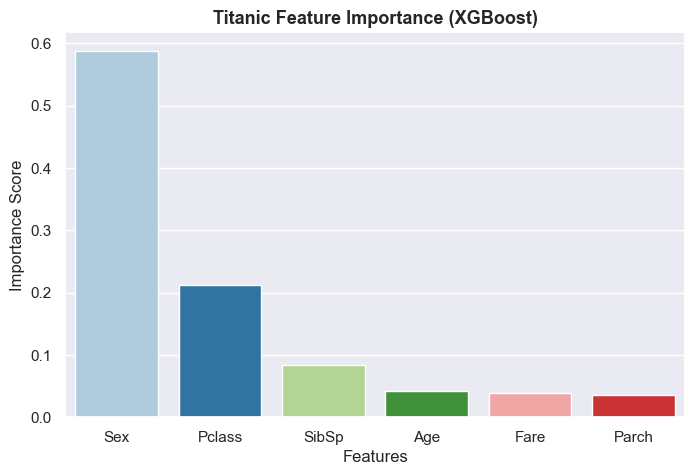

In [6]:
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(8, 5))

sns.barplot(data=feature_importance_df, x='Feature', y='Importance', palette='Paired', hue='Feature')

plt.title('Titanic Feature Importance (XGBoost)', fontsize=13, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.show()

In [7]:
gender_rates = df.groupby('Sex')['Survived'].mean()
print("--- Overall Survival Rates by Gender ---")
for gender, rate in gender_rates.items():
    print(f"{rate:.2%} of {gender}s survived")

print("\n--- Detailed Breakdown by Class and Gender ---")
class_gender_rates = (
    df.groupby(['Pclass', 'Sex'])['Survived']
      .mean()
      .reset_index()
)

for _, row in class_gender_rates.iterrows():
    suffix = {1: "st", 2: "nd", 3: "rd"}.get(row['Pclass'], 'th')
    print(f"{row['Pclass']}{suffix}-Class {row['Sex'].capitalize()}: {row['Survived']:.2%} survived")


--- Overall Survival Rates by Gender ---
74.20% of females survived
18.89% of males survived

--- Detailed Breakdown by Class and Gender ---
1st-Class Female: 96.81% survived
1st-Class Male: 36.89% survived
2nd-Class Female: 92.11% survived
2nd-Class Male: 15.74% survived
3rd-Class Female: 50.00% survived
3rd-Class Male: 13.54% survived
